In [ ]:
from tkinter import Tk
from tkinter.fieldialog import askopenfilename
import matplotlib.pyplot as plt

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

cpu


In [4]:
CLASS_NAMES = [
    "asteroid",
    "black_hole",
    "earth",
    "galaxy",
    "jupiter",
    "mars",
    "mercury",
    "neptune",
    "pluto",
    "saturn",
    "uranus",
    "venus"
]

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x

In [14]:
MODEL_PATH = Path("../models/simple_cnn.pth")
model = SimpleCNN(num_classes=len(CLASS_NAMES))
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model loaded successdully!")

Model loaded successdully!


In [16]:
IMAGE_PATH = Path(
    "../datasets/raw/astro_dataset_maxia/test/galaxy/galaxy_009.jpg"
)

(np.float64(-0.5), np.float64(835.5), np.float64(476.5), np.float64(-0.5))

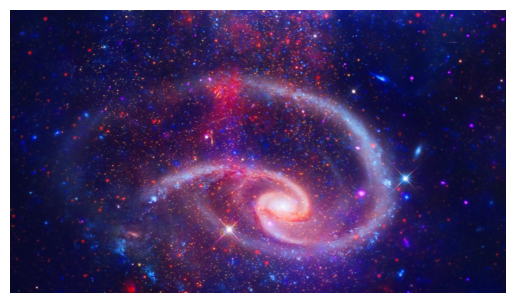

In [17]:
image = Image.open(IMAGE_PATH).convert("RGB")
plt.imshow(image)
plt.axis("off")

In [18]:
input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)
input_tensor = input_tensor.to(device)
print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [19]:
# prediction
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(
        outputs,
        dim=1
    )
    
    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

In [20]:
# result display
predicted_class = CLASS_NAMES[
    prediction.item()
]
print("=" * 40)
print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence.item()*100:.2f}%")
print("=" * 40)

Prediction : galaxy
Confidence : 100.00%


In [22]:
# top 5 predictions
top5_prob, top5_idx = torch.topk(
    probabilities,
    k=5
)
print("Top 5 Predictions\n")

for prob, idx in zip(
    top5_prob[0],
    top5_idx[0]
):
    print(f"{CLASS_NAMES[idx]} : {prob.item()*100:.2f}%"
    )

Top 5 Predictions

galaxy : 100.00%
black_hole : 0.00%
asteroid : 0.00%
earth : 0.00%
neptune : 0.00%


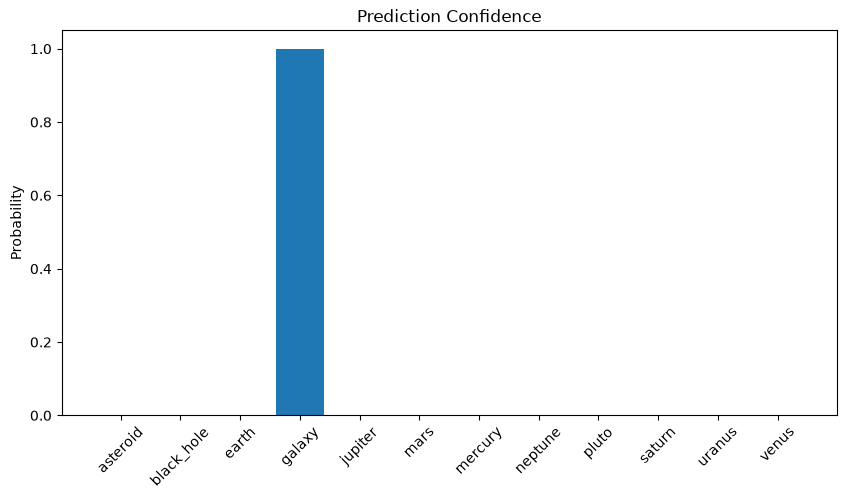

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    CLASS_NAMES,
    probabilities.cpu().numpy()[0]
)

plt.xticks(rotation=45)

plt.ylabel("Probability")

plt.title("Prediction Confidence")

plt.show()